In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CTS_CRM_Objection_Annotated_3000_ContextAware.csv to CTS_CRM_Objection_Annotated_3000_ContextAware (1).csv


In [ ]:
#Load the dataset
df = pd.read_csv(
    "CTS_CRM_Objection_Annotated_3000_ContextAware.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (3000, 20)


In [ ]:
#Inspect the dataset
df.head()
df.columns

Index(['interaction_id', 'crm_note_id', 'interaction_date', 'rep_id', 'hcp_id',
       'city', 'region', 'territory_id', 'hcp_specialization',
       'therapeutic_area', 'drug_id', 'drug_name', 'brand_name', 'crm_note',
       'clean_text', 'objection_label', 'annotation_confidence',
       'annotation_rationale', 'annotation_method', 'annotation_status'],
      dtype='object')

In [ ]:
#Check the objection distribution
df["objection_label"].value_counts()

,count
objection_label,
No Objection,335
Adherence,334
Dosing / Administration,333
Cost / Affordability,333
Access / Reimbursement,333
Evidence / Clinical Data,333
Competitor,333
Safety / Tolerability,333
Efficacy / Clinical Benefit,333


In [ ]:
#Check for missing values
print("Missing clean_text:",
      df["clean_text"].isna().sum())

print("Missing objection_label:",
      df["objection_label"].isna().sum())

Missing clean_text: 0
Missing objection_label: 0


In [ ]:
print(
    "Empty clean_text:",
    df["clean_text"].str.strip().eq("").sum()
)

Empty clean_text: 0


In [ ]:
#Define X and y
X = df["clean_text"]
y = df["objection_label"]

In [ ]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2400
Testing samples: 600


In [ ]:
#Import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (2400, 3387)
Testing TF-IDF shape: (600, 3387)


In [ ]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 3387

First 50 features:
['abdominal' 'abdominal discomfort' 'acceptance' 'acceptance among'
 'access' 'access consideration' 'access fast' 'access follow'
 'access manageable' 'access prior' 'access uneven' 'access unpredictable'
 'across' 'across hcp' 'across patient' 'across plan' 'action'
 'action access' 'action affordability' 'action availability'
 'action clinical' 'action differentiation' 'action dose'
 'action efficacy' 'action interaction' 'action patient' 'action provide'
 'action safety' 'action tolerability' 'actionable' 'actionable barrier'
 'add' 'add support' 'additional' 'additional ask' 'additional major'
 'additional material' 'additional safety' 'address' 'address main'
 'address no' 'address remain' 'adherence' 'adherence concern'
 'adherence improve' 'adherence remain' 'adherence support'
 'adherence weak' 'adherence weaker' 'adjustment']


In [ ]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
#Train the model
logreg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Make predictions on unseen data
y_pred = logreg.predict(X_test_tfidf)
for text, actual, predicted in zip(
    X_test.head(10),
    y_test.head(10),
    y_pred[:10]
):
    print("CRM:", text)
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 70)

CRM: meet gastrel current regimen practical patient recent outcome favorable hcp less fix gutavex prior visit hcp worry regiman hard reinforce no major issue today
Actual: Efficacy / Clinical Benefit
Predicted: Efficacy / Clinical Benefit
----------------------------------------------------------------------
CRM: field visit hcp discuss clinical experience practical consideration medicura patient show limited response prior authorization burden remain high office
Actual: Efficacy / Clinical Benefit
Predicted: Efficacy / Clinical Benefit
----------------------------------------------------------------------
CRM: hcp give detailed update arthrelis consider practice barrier remain adherence remain practical concern hcp request patient support material address remain question document follow commitment due
Actual: Adherence
Predicted: Adherence
----------------------------------------------------------------------
CRM: discussion cover recent patient experience access consideration questio

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.9233


In [ ]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                             precision    recall  f1-score   support

     Access / Reimbursement       1.00      0.94      0.97        66
                  Adherence       0.99      0.99      0.99        67
                 Competitor       0.90      0.97      0.93        66
       Cost / Affordability       0.97      0.93      0.95        67
    Dosing / Administration       0.89      0.94      0.91        67
Efficacy / Clinical Benefit       0.86      0.88      0.87        67
   Evidence / Clinical Data       0.97      0.89      0.93        66
               No Objection       0.82      0.84      0.83        67
      Safety / Tolerability       0.94      0.94      0.94        67

                   accuracy                           0.92       600
                  macro avg       0.93      0.92      0.92       600
               weighted avg       0.93      0.92      0.92       600



In [ ]:
#Macro-F1
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("Macro-F1:", round(macro_f1, 4))

Macro-F1: 0.9238


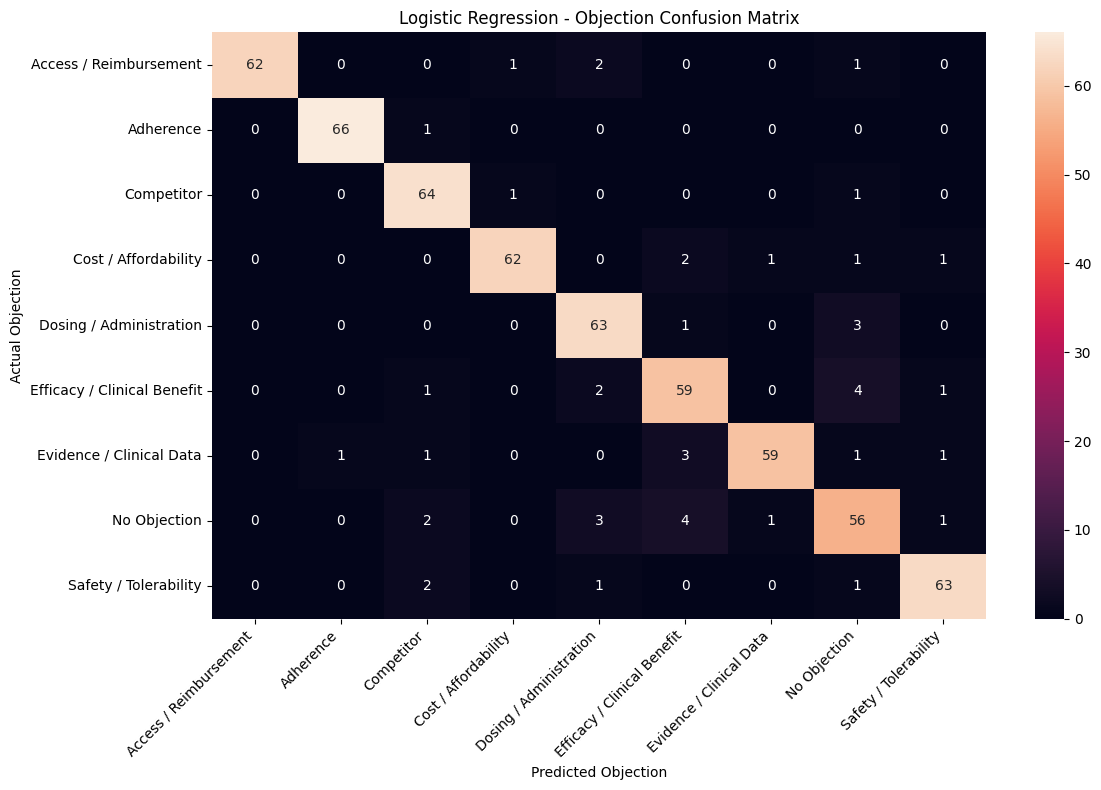

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=logreg.classes_
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=logreg.classes_,
    yticklabels=logreg.classes_
)

plt.xlabel("Predicted Objection")
plt.ylabel("Actual Objection")
plt.title("Logistic Regression - Objection Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()